In [ ]:
library(ggplot2)
library(dplyr)

install.packages("ggplot2")
install.packages("dplyr")

print("Libraries loaded")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Libraries loaded"


In [ ]:
customers  <- read.csv("customers.csv")
drivers    <- read.csv("drivers.csv")
vehicles   <- read.csv("vehicles.csv")
hubs       <- read.csv("hubs.csv")
orders     <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
incidents  <- read.csv("incidents.csv")
complaints <- read.csv("complaints.csv")
app_events <- read.csv("app_events.csv")

cat("All datasets loaded\n")
cat("Orders:", nrow(orders), "rows\n")
cat("Deliveries:", nrow(deliveries), "rows\n")

All datasets loaded
Orders: 1250 rows
Deliveries: 950 rows


In [ ]:
zone_map <- c(
  "NORTH" = "North", "north" = "North",
  "SOUTH" = "South",
  "EAST" = "East",
  "WEST" = "West",
  "CENTRAL" = "Central", "Ctr" = "Central",
  "AIRPORT" = "Airport",
  "RiverSide" = "Riverside"
)

fix_zones <- function(df, cols) {
  for (col in cols) {
    df[[col]] <- ifelse(df[[col]] %in% names(zone_map),
                        zone_map[df[[col]]],
                        df[[col]])
  }
  return(df)
}

customers  <- fix_zones(customers,  c("home_zone"))
drivers    <- fix_zones(drivers,    c("base_zone"))
vehicles   <- fix_zones(vehicles,   c("assigned_zone"))
orders     <- fix_zones(orders,     c("pickup_zone", "dropoff_zone"))

cat("Zones cleaned\n")
cat("Unique zones:", paste(sort(unique(customers$home_zone)), collapse=", "), "\n")

Zones cleaned
Unique zones: Airport, Central, East, North, Riverside, South, West 


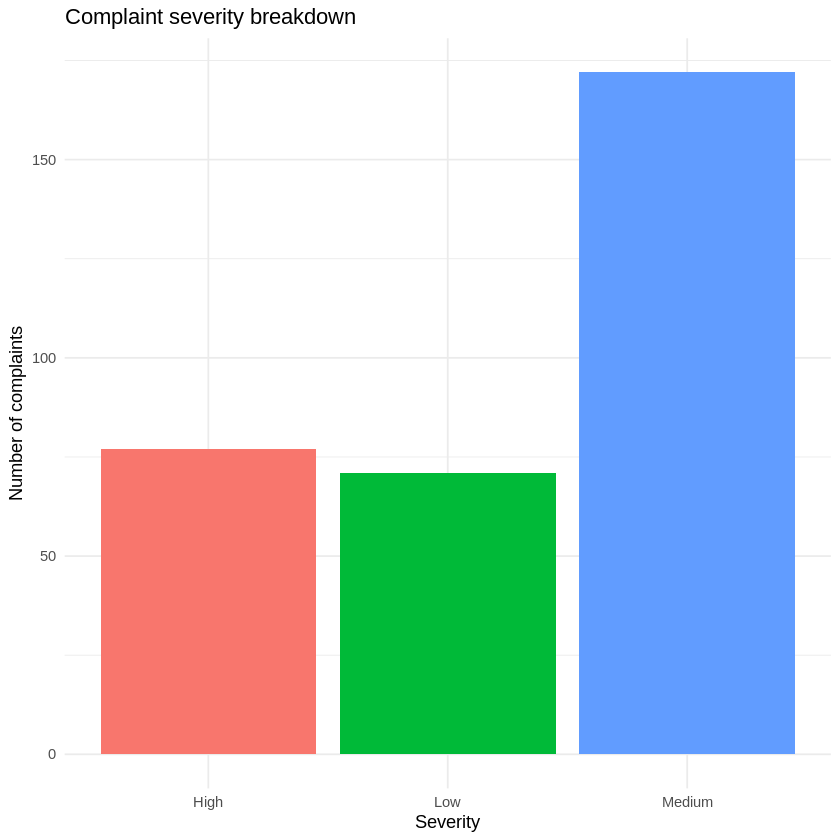

In [ ]:
complaint_severity <- complaints %>%
  group_by(severity) %>%
  summarise(count = n())

ggplot(complaint_severity, aes(x = severity, y = count, fill = severity)) +
  geom_bar(stat = "identity") +
  labs(title = "Complaint severity breakdown",
       x = "Severity", y = "Number of complaints") +
  theme_minimal() +
  theme(legend.position = "none")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”


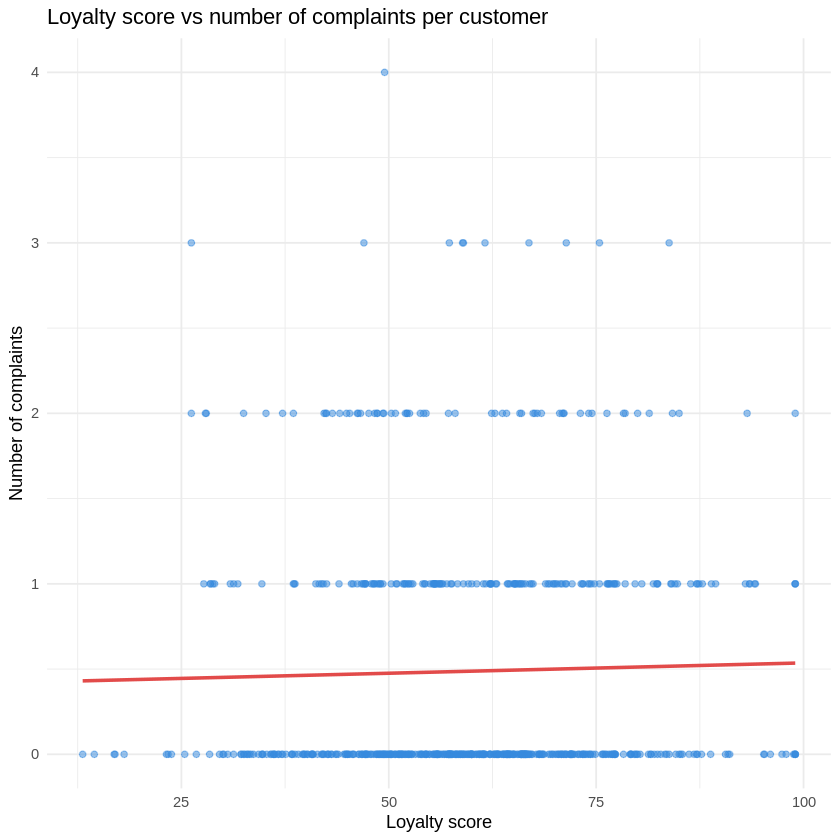

In [ ]:
# Join customers with complaint counts
complaint_counts <- complaints %>%
  group_by(customer_id) %>%
  summarise(complaint_count = n())

customers_complaints <- merge(customers, complaint_counts,
                               on="customer_id", all.x=TRUE)
customers_complaints$complaint_count[is.na(customers_complaints$complaint_count)] <- 0

ggplot(customers_complaints, aes(x = loyalty_score, y = complaint_count)) +
  geom_point(alpha = 0.5, color = "#378ADD") +
  geom_smooth(method = "lm", color = "#E24B4A", se = FALSE) +
  labs(title = "Loyalty score vs number of complaints per customer",
       x = "Loyalty score", y = "Number of complaints") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


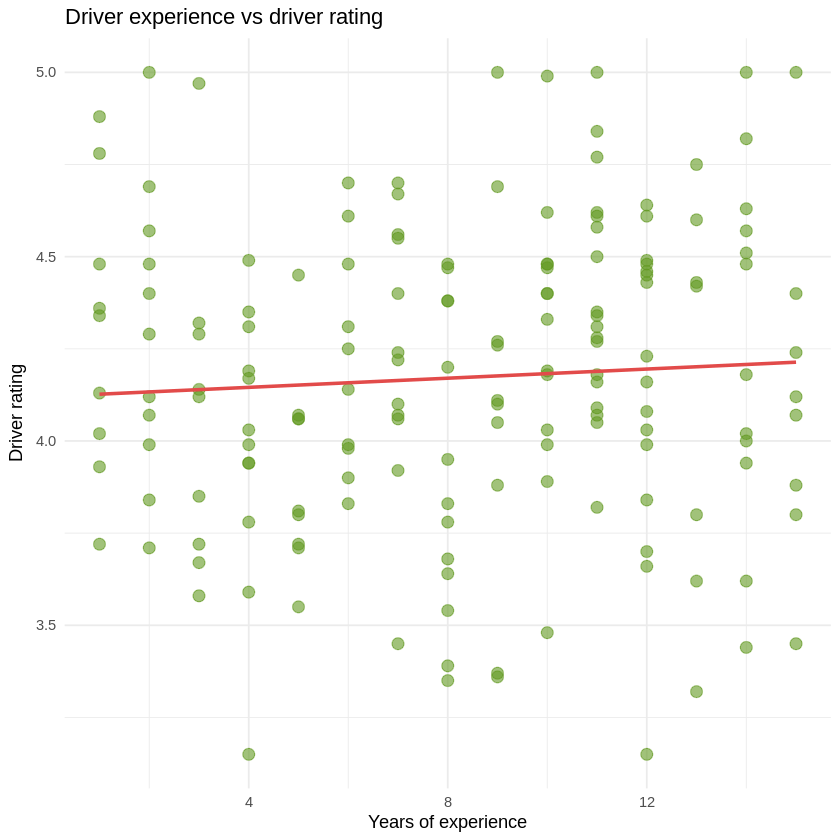

In [ ]:
ggplot(drivers, aes(x = years_experience, y = driver_rating)) +
  geom_point(alpha = 0.6, color = "#639922", size = 3) +
  geom_smooth(method = "lm", color = "#E24B4A", se = FALSE) +
  labs(title = "Driver experience vs driver rating",
       x = "Years of experience", y = "Driver rating") +
  theme_minimal()

Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


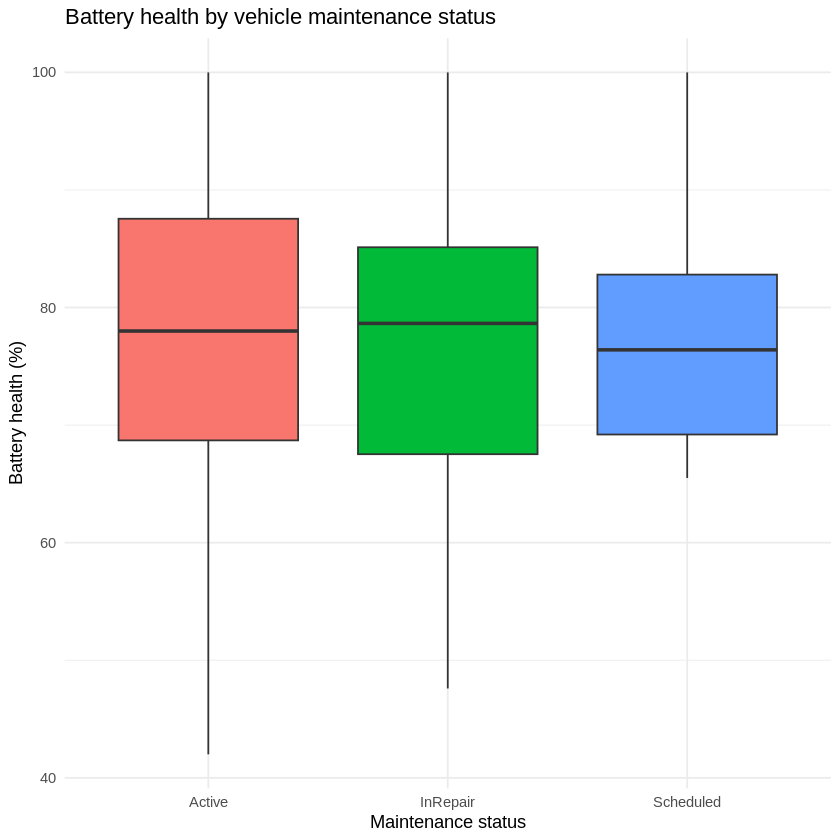

In [ ]:
ggplot(vehicles, aes(x = maintenance_status, y = battery_health_pct, fill = maintenance_status)) +
  geom_boxplot() +
  labs(title = "Battery health by vehicle maintenance status",
       x = "Maintenance status", y = "Battery health (%)") +
  theme_minimal() +
  theme(legend.position = "none")